In [71]:
import palantir
import scanpy as sc
import pandas as pd
import os

# Plotting
import matplotlib
import matplotlib.pyplot as plt

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

# Inline plotting
%matplotlib inline

In [72]:
# Load sample data

data_dir = os.path.expanduser("./")

download_url = "https://dp-lab-data-public.s3.amazonaws.com/palantir/marrow_sample_scseq_counts.h5ad"
file_path = os.path.join(data_dir, "marrow_sample_scseq_counts.h5ad")

ad = sc.read(file_path, backup_url=download_url)
ad

AnnData object with n_obs × n_vars = 4142 × 16106

In [73]:
sc.pp.normalize_per_cell(ad)

palantir.preprocess.log_transform(ad)

sc.pp.highly_variable_genes(ad, n_top_genes=1500, flavor="cell_ranger")

/tmp/ipykernel_56494/1137013193.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(ad)
/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


In [74]:
# Note in the manuscript, we did not use highly variable genes but scanpy by default uses only highly variable genes

sc.pp.pca(ad)

ad

AnnData object with n_obs × n_vars = 4142 × 16106
    obs: 'n_counts'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [75]:
str(ad)

"AnnData object with n_obs × n_vars = 4142 × 16106\n    obs: 'n_counts'\n    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'\n    uns: 'hvg', 'pca'\n    obsm: 'X_pca'\n    varm: 'PCs'"

In [76]:
ad.obs.head()

,n_counts
Run4_120703408880541,7937.0
Run4_120703409056541,4829.0
Run4_120703409580963,4679.0
Run4_120703423990708,5863.0
Run4_120703436876077,6861.0


In [77]:
ad.var.head()

,highly_variable,means,dispersions,dispersions_norm
KCTD15,False,0.170087,3.130907,-1.433739
STT3B,False,1.716775,2.125067,-0.282248
NAT6,False,0.390413,3.133187,1.145561
FHL2,True,0.492890,3.196508,3.390091
SP140L,False,0.382467,3.116901,0.054302


In [78]:
ad.uns

OrderedDict([('hvg', {'flavor': 'cell_ranger'}),
             ('pca',
              {'params': {'zero_center': True,
                'use_highly_variable': True,
                'mask_var': 'highly_variable'},
               'variance': array([89.34293  , 57.531387 , 44.59853  , 17.139496 , 11.81296  ,
                      11.03758  ,  9.456354 ,  7.677406 ,  6.28666  ,  5.9428945,
                       5.376779 ,  5.1194873,  4.944793 ,  4.6675625,  4.5092993,
                       4.400803 ,  4.2878575,  4.2017756,  4.1565394,  4.1310244,
                       4.0912066,  4.0207777,  3.9883006,  3.9515994,  3.8974836,
                       3.8470109,  3.838958 ,  3.8147838,  3.7372308,  3.7271006,
                       3.717419 ,  3.6881707,  3.659389 ,  3.6370165,  3.6357443,
                       3.6073306,  3.598219 ,  3.5631647,  3.5287602,  3.5035179,
                       3.499742 ,  3.4813745,  3.4650354,  3.455431 ,  3.412901 ,
                       3.4105322,  3.398

In [79]:
ad.uns['hvg']

{'flavor': 'cell_ranger'}

In [80]:
ad.uns['pca']['variance_ratio'][:10]    # fraction of variance per PC
ad.uns['pca']['params']   

{'zero_center': True,
 'use_highly_variable': True,
 'mask_var': 'highly_variable'}

In [81]:
ad.obsm['X_pca']

array([[ -8.871559  , -12.547667  ,  -3.6605146 , ...,   1.089942  ,
          1.5823991 ,  -2.3015454 ],
       [ -6.685028  ,   5.653689  ,   4.5920815 , ...,  -1.7379754 ,
         -1.3798653 ,   2.1992824 ],
       [ 18.126862  ,  -5.267556  ,   4.546576  , ...,   2.8993857 ,
          0.89244604,   3.3861132 ],
       ...,
       [ -1.7370174 ,   8.017513  ,   2.9076636 , ...,   1.4936693 ,
          0.68438107,   0.6820475 ],
       [  5.2724094 ,   5.67954   ,  -4.6690426 , ...,  -1.7978094 ,
         -1.7297822 ,   0.06827246],
       [ -6.8696218 , -18.41451   ,  -8.961578  , ...,   0.70442724,
         -0.76911765,  -1.009862  ]], dtype=float32)

In [82]:
ad.varm['PCs']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [83]:
sc.pp.highly_variable_genes(ad, n_top_genes=1500, flavor="cell_ranger")

# PCA
# Note in the manuscript, we did not use highly variable genes but scanpy by default uses only highly variable genes

sc.pp.pca(ad)
ad

AnnData object with n_obs × n_vars = 4142 × 16106
    obs: 'n_counts'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [84]:
# Diffusion maps

dm_res = palantir.utils.run_diffusion_maps(ad, n_components=5)

ms_data = palantir.utils.determine_multiscale_space(ad)

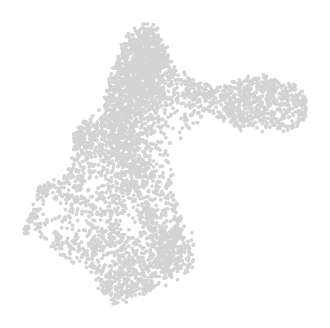

In [85]:
# Visualization

sc.pp.neighbors(ad)
sc.tl.umap(ad)

# Use scanpy functions to visualize umaps or FDL

sc.pl.embedding(
    ad,
    basis="umap",
    frameon=False,
)

In [86]:
# MAGIC imputation
# Palantir uses MAGIC to impute the data for visualization and determining gene expression trends.

In [87]:
imputed_X = palantir.utils.run_magic_imputation(ad)

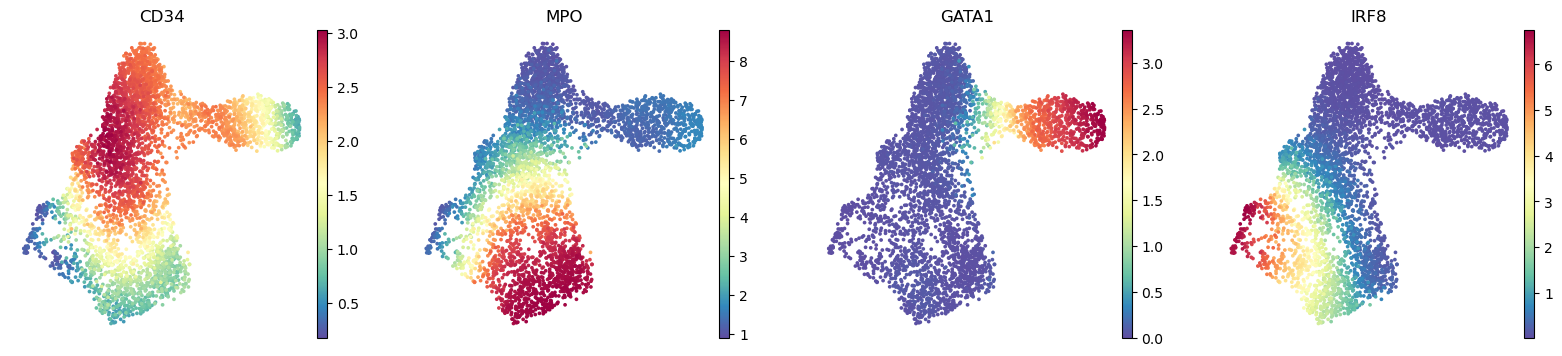

In [88]:
sc.pl.embedding(
    ad,
    basis="umap",
    layer="MAGIC_imputed_data",
    color=["CD34", "MPO", "GATA1", "IRF8"],
    frameon=False,
)
plt.show()

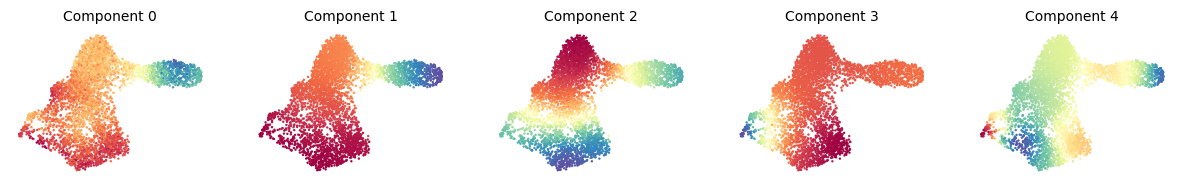

In [89]:
# Diffusion maps visualization

palantir.plot.plot_diffusion_components(ad)
plt.show()

In [90]:
# Running Palantir
# Palantir can automatically determine the terminal states as well. 
# In this dataset, we know the terminal states and we will set them using the terminal_states parameter

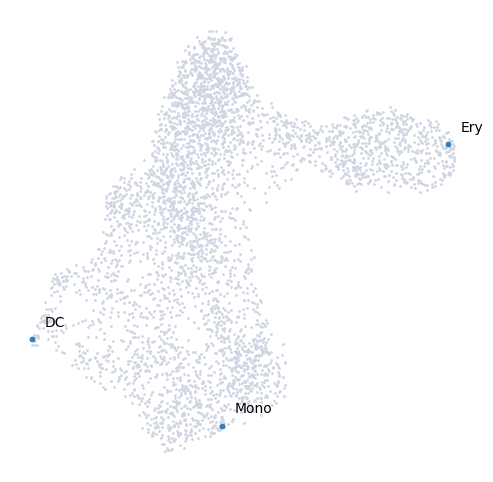

In [91]:
terminal_states = pd.Series(
    ["DC", "Mono", "Ery"],
    index=["Run5_131097901611291", "Run5_134936662236454", "Run4_200562869397916"],
)

palantir.plot.highlight_cells_on_umap(ad, terminal_states)
plt.show()

Sampling and flocking waypoints...
Time for determining waypoints: 6.346305211385091e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.017272015412648518 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


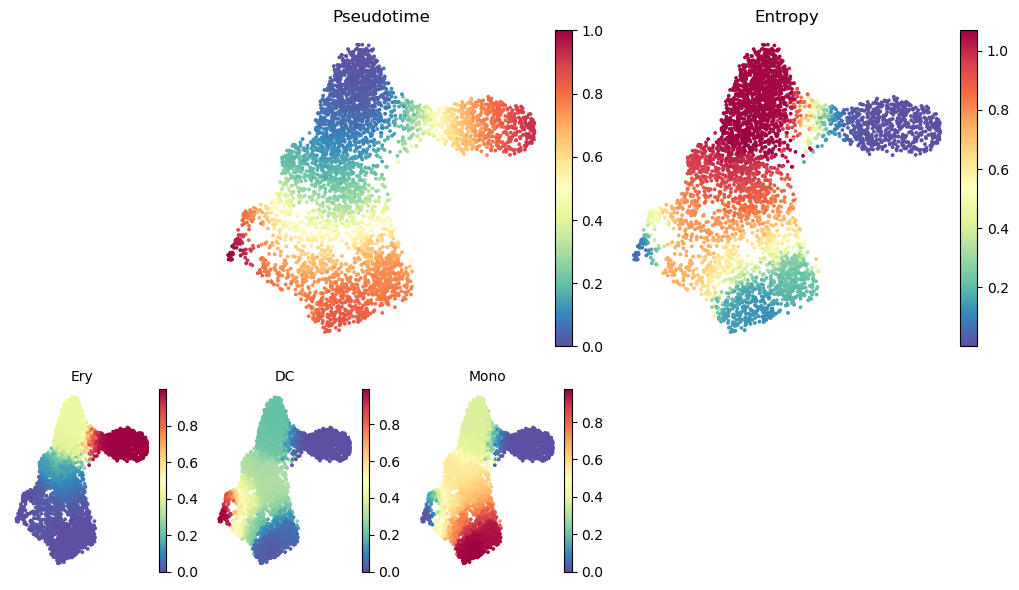

In [92]:
start_cell = "Run5_164698952452459"

pr_res = palantir.core.run_palantir(
    ad, start_cell, num_waypoints=500, terminal_states=terminal_states
)

# Visualizing Palantir results
palantir.plot.plot_palantir_results(ad, s=3)
plt.show()

In [93]:
# Pseudotime: Pseudo time ordering of each cell

# Terminal state probabilities: Matrix of cells X terminal states. 
# Each entry represents the probability of the corresponding cell reaching the respective terminal state

# Entropy: A quantiative measure of the differentiation potential of each cell computed as the entropy of 
# the multinomial terminal state probabilities

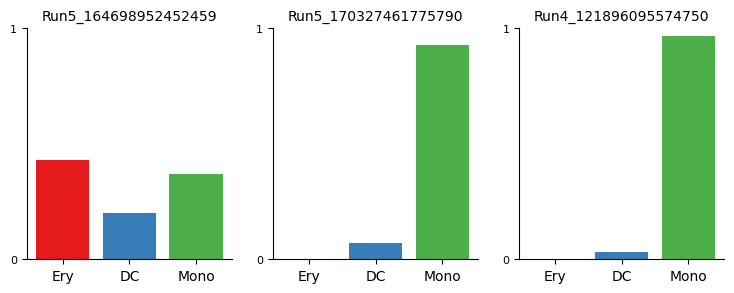

In [94]:
cells = [
    "Run5_164698952452459",
    "Run5_170327461775790",
    "Run4_121896095574750",
]

palantir.plot.plot_terminal_state_probs(ad, cells)
plt.show()

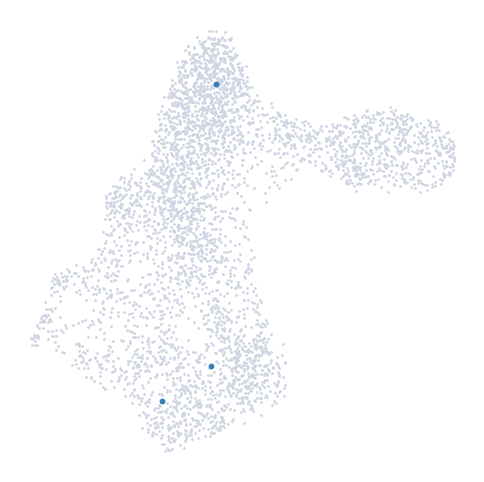

In [95]:
palantir.plot.highlight_cells_on_umap(ad, cells)
plt.show()

In [96]:
print("Gene expression trends")

Gene expression trends


In [97]:
print("""Gene expression trends over pseudotime provide insights into the dynamic behavior of genes during
cellular development or progression.""")

print("""Gene expression trends over pseudotime provide insights into the dynamic behavior of genes during
cellular development or progression. By examining these trends, we can uncover the timing of gene expression
changes and identify pivotal regulators of cellular states.
Palantir provides tools for computing these gene expression trends.""")

Gene expression trends over pseudotime provide insights into the dynamic behavior of genes during
cellular development or progression.
Gene expression trends over pseudotime provide insights into the dynamic behavior of genes during
cellular development or progression. By examining these trends, we can uncover the timing of gene expression
changes and identify pivotal regulators of cellular states.
Palantir provides tools for computing these gene expression trends.


In [98]:
print("Gene expression trends - select branch cells")

Gene expression trends - select branch cells


In [99]:
print("""Before computing the gene expression trends, we first need to select cells associated 
with a specific branch of the pseudotime trajectory.

We accomplish this by using the select_branch_cells function. 

The parameters q and eps are used to control the selection's tolerance. 
Select small values >=0 to be more sringent and larger values <1 to select more cells.""")

Before computing the gene expression trends, we first need to select cells associated 
with a specific branch of the pseudotime trajectory.

We accomplish this by using the select_branch_cells function. 

The parameters q and eps are used to control the selection's tolerance. 
Select small values >=0 to be more sringent and larger values <1 to select more cells.


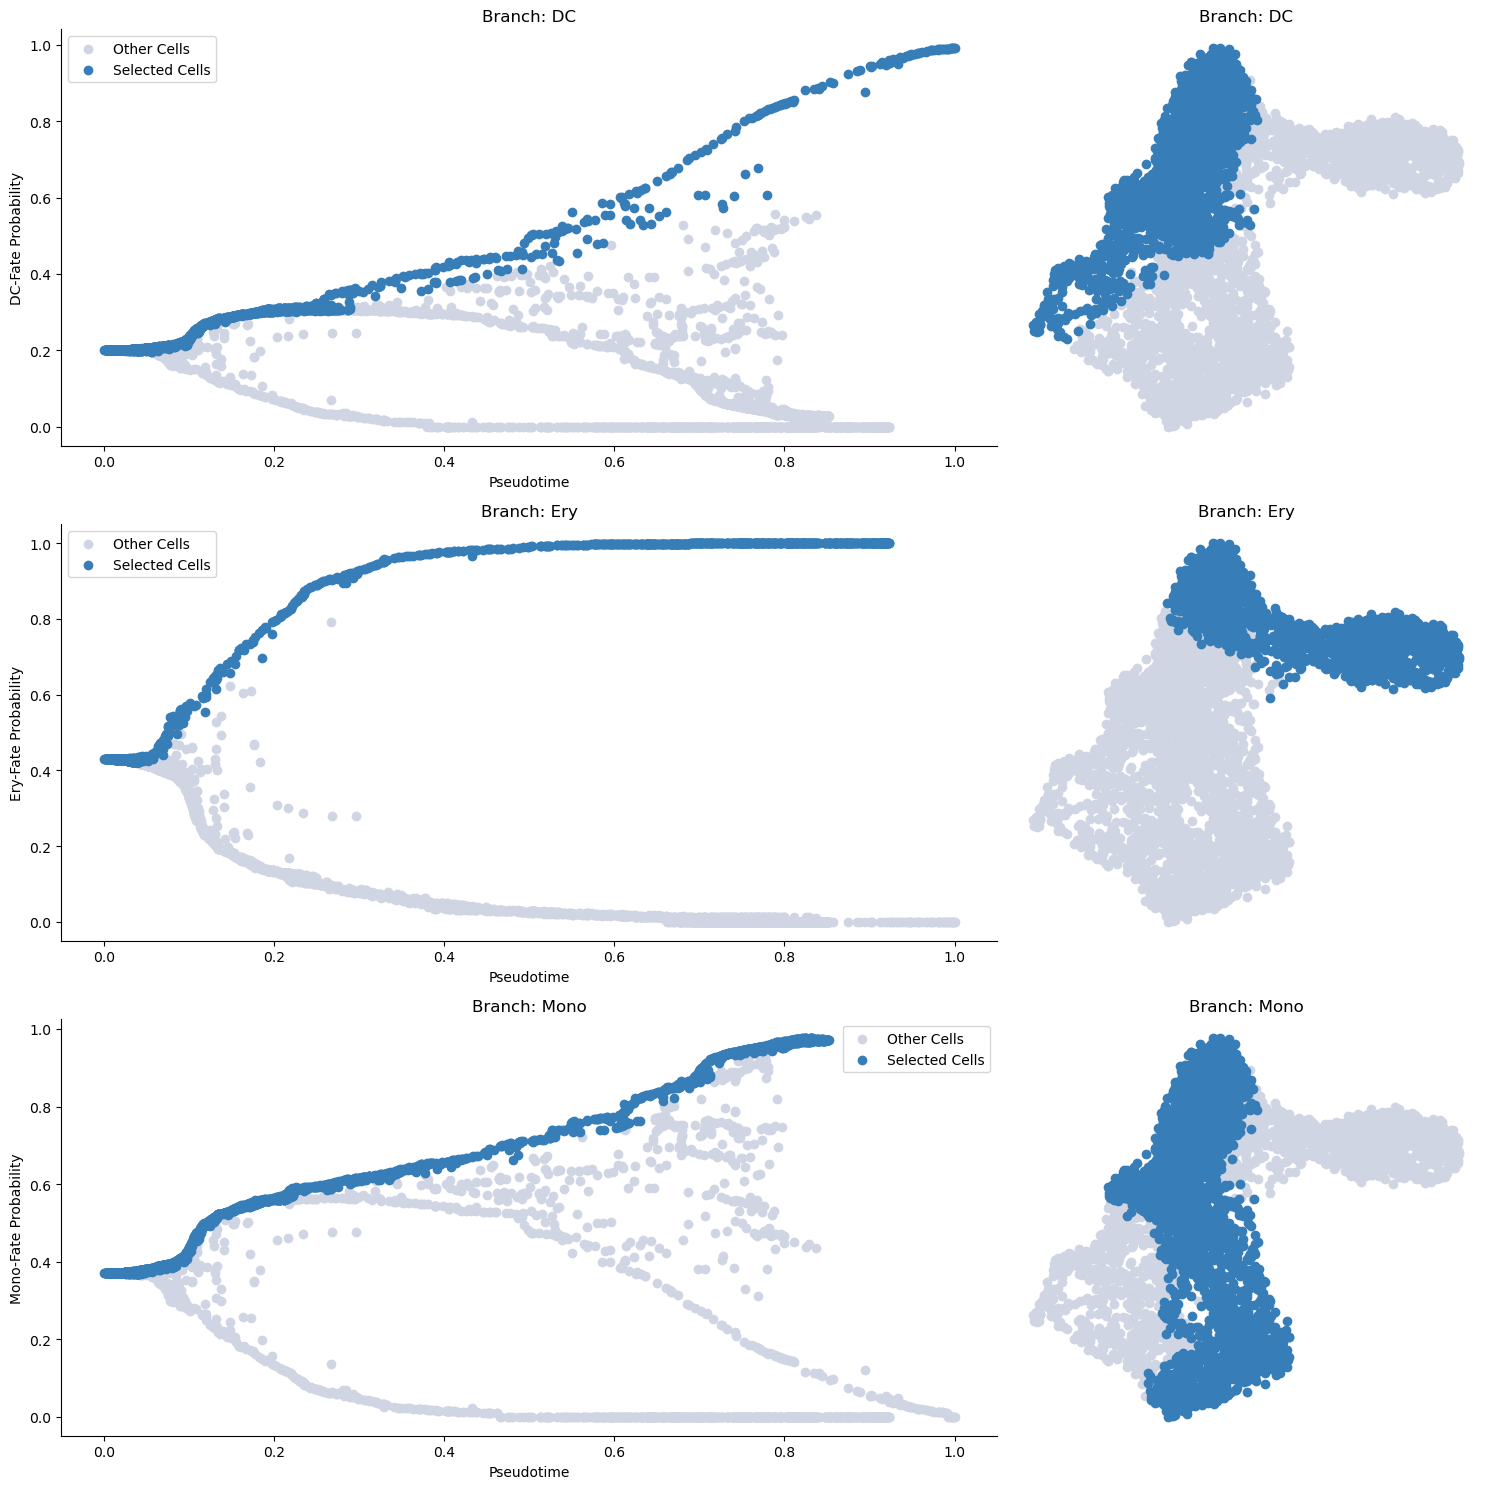

In [100]:
# Gene expression trends - select branch cells

masks = palantir.presults.select_branch_cells(ad, q=.01, eps=.01)

palantir.plot.plot_branch_selection(ad)
plt.show()


[2026-07-18 13:03:34,388] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,512) and rank = 1.0.
[2026-07-18 13:03:34,389] [INFO    ] Using covariance function Matern52(ls=1.0721113204956054).
[2026-07-18 13:03:34,390] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-07-18 13:03:34,423] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-07-18 13:03:34,447] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,936) and rank = 1.0.
[2026-07-18 13:03:34,448] [INFO    ] Using covariance function Matern52(ls=1.0721113204956054).
[2026-07-18 13:03:34,448] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-07-18 13:03:34,531] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: DC'}, xlabel='UMAP1', ylabel='UMAP2'>

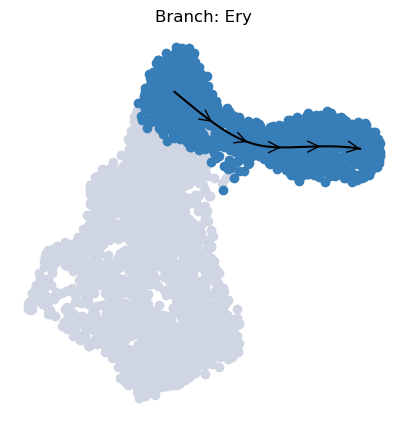

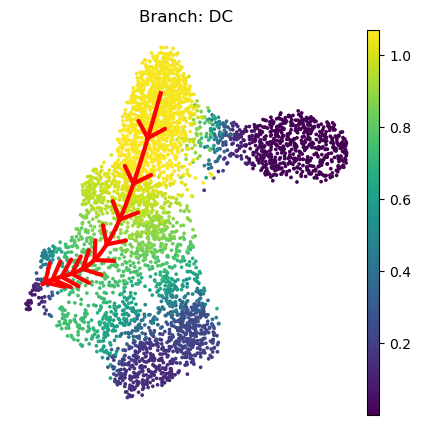

In [101]:
# To visualize a trajectory on the UMAP, we interpolate the UMAP coordinates of cells specific to each branch across pseudotime, 
# enabling us to draw a continuous path.

palantir.plot.plot_trajectory(ad, "Ery")

palantir.plot.plot_trajectory(
    ad, # your anndata
    "DC", # the branch to plot
    cell_color="palantir_entropy", # the ad.obs colum to color the cells by
    n_arrows=10, # the number of arrow heads along the path
    color="red", # the color of the path and arrow heads
    scanpy_kwargs=dict(cmap="viridis"), # arguments passed to scanpy.pl.embedding
    arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3), # appearance of the arrow heads
    lw=3, # thickness of the path
    pseudotime_interval=(0, .9), # interval of the pseudotime to cover with the path
)


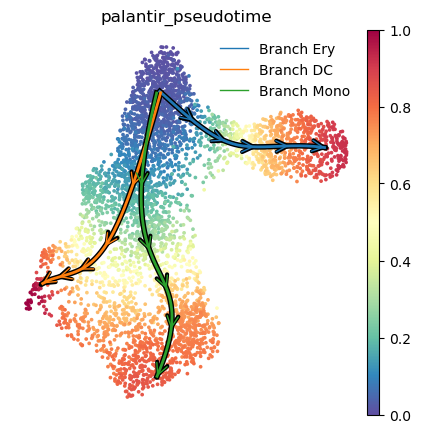

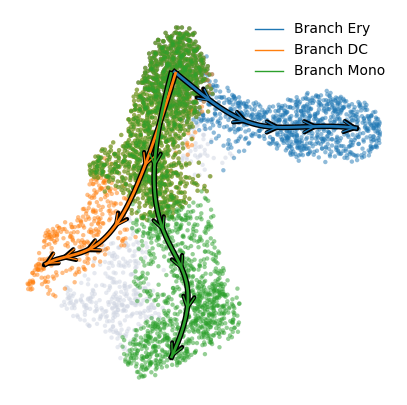

In [102]:
palantir.plot.plot_trajectories(ad, pseudotime_interval=(0, .9))

# When using cell_color="branch_selection" be aware of the overlap between branches:

palantir.plot.plot_trajectories(ad, cell_color="branch_selection", pseudotime_interval=(0, .9))
plt.show()

Ery
[2026-07-18 13:03:35,991] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,512) and rank = 1.0.
[2026-07-18 13:03:35,992] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-07-18 13:03:36,018] [INFO    ] Sigma interpreted as element-wise standard deviation.
DC
[2026-07-18 13:03:36,746] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,936) and rank = 1.0.
[2026-07-18 13:03:36,747] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-07-18 13:03:36,773] [INFO    ] Sigma interpreted as element-wise standard deviation.
Mono
[2026-07-18 13:03:37,722] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,611) and rank = 1.0.
[2026-07-18 13:03:37,723] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-07-18 13:03:37,758] [INFO    ] Sigma interpreted as element-wise standard deviation.


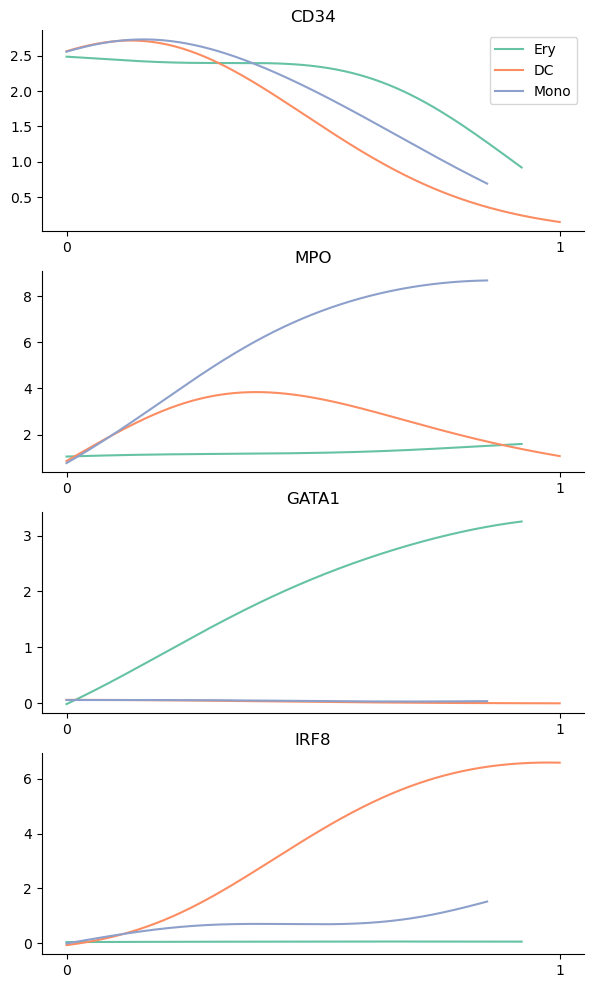

In [103]:
# Gene expression trends

gene_trends = palantir.presults.compute_gene_trends(
    ad,
    expression_key="MAGIC_imputed_data",
)

genes = ["CD34", "MPO", "GATA1", "IRF8"]
palantir.plot.plot_gene_trends(ad, genes)
plt.show()


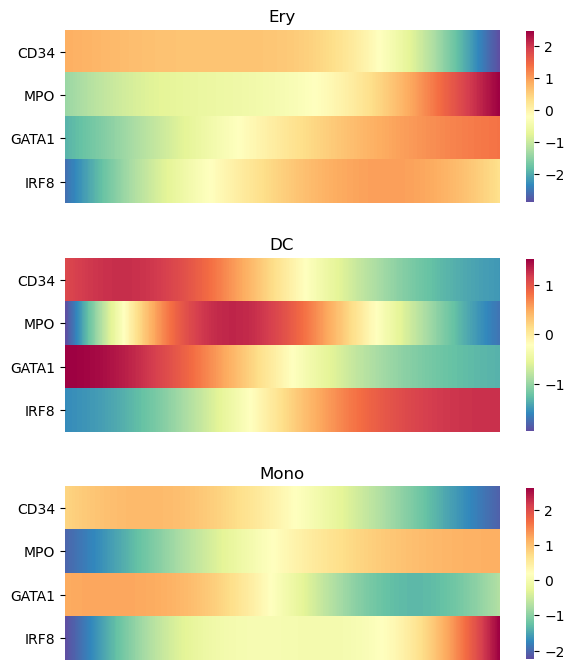

In [104]:
# Alternatively, the trends can be visualized on a heatmap using

palantir.plot.plot_gene_trend_heatmaps(ad, genes)
plt.show()

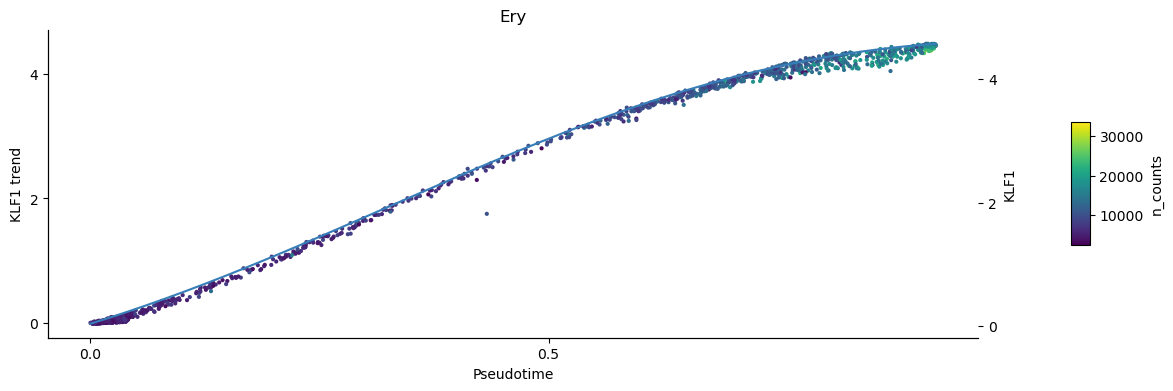

In [105]:
palantir.plot.plot_trend(ad, "Ery", "KLF1", color="n_counts", position_layer="MAGIC_imputed_data")
plt.show()

In [106]:
print("Clustering")

Clustering


In [107]:
# Clustering

more_genes = ad.var_names[:1000]
communities = palantir.presults.cluster_gene_trends(ad, "Ery", more_genes)


/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


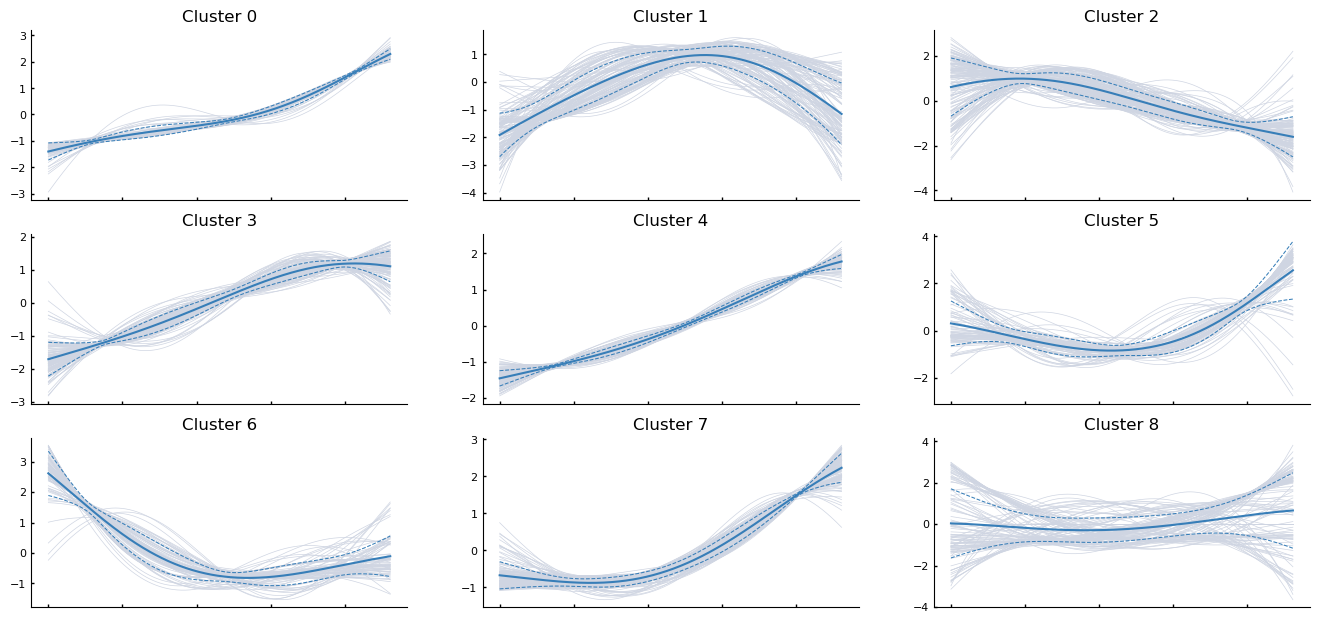

In [108]:

palantir.plot.plot_gene_trend_clusters(ad, "Ery")
plt.show()


[2026-07-18 13:03:39,648] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,936) and rank = 1.0.
[2026-07-18 13:03:39,649] [INFO    ] Using covariance function Matern52(ls=1.0721113204956054).
[2026-07-18 13:03:39,649] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-07-18 13:03:39,664] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: DC'}, xlabel='UMAP1', ylabel='UMAP2'>

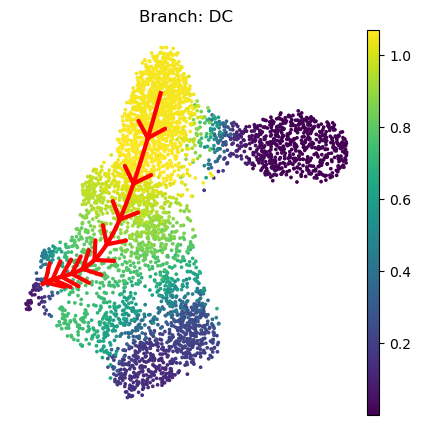

In [109]:
palantir.plot.plot_trajectory(
    ad, # your anndata
    "DC", # the branch to plot
    cell_color="palantir_entropy", # the ad.obs colum to color the cells by
    n_arrows=10, # the number of arrow heads along the path
    color="red", # the color of the path and arrow heads
    scanpy_kwargs=dict(cmap="viridis"), # arguments passed to scanpy.pl.embedding
    arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3), # appearance of the arrow heads
    lw=3, # thickness of the path
    pseudotime_interval=(0, .9), # interval of the pseudotime to cover with the path
)

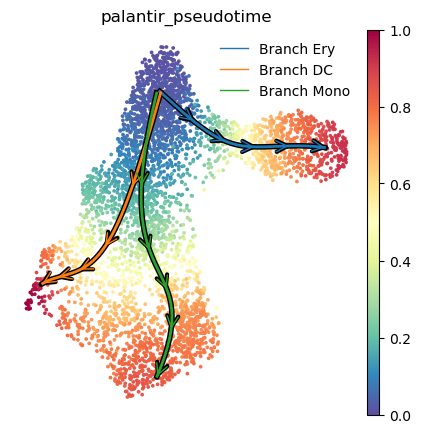

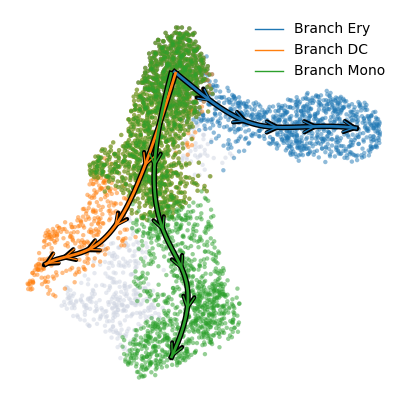

In [110]:
palantir.plot.plot_trajectories(ad, pseudotime_interval=(0, .9))
# When using cell_color="branch_selection" be aware of the overlap between branches:
palantir.plot.plot_trajectories(ad, cell_color = "branch_selection", pseudotime_interval=(0, .9))
plt.show()

In [ ]:
gene_trends = palantir.presults.compute_gene_trends(
    ad,
    expression_key="MAGIC_imputed_data",
)

Ery
[2026-07-18 13:03:41,412] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,512) and rank = 1.0.
[2026-07-18 13:03:41,413] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-07-18 13:03:41,433] [INFO    ] Sigma interpreted as element-wise standard deviation.


In [ ]:
genes = ["CD34", "MPO", "GATA1", "IRF8"]
palantir.plot.plot_gene_trends(ad, genes)
plt.show()

In [ ]:
palantir.plot.plot_gene_trend_heatmaps(ad, genes)
plt.show()

In [ ]:
palantir.plot.plot_trend(ad, "Ery", "KLF1", color="n_counts", position_layer="MAGIC_imputed_data")
plt.show()

In [ ]:
more_genes = ad.var_names[:1000]
communities = palantir.presults.cluster_gene_trends(ad, "Ery", more_genes)

In [ ]:
palantir.plot.plot_gene_trend_clusters(ad, "Ery")
plt.show()

In [ ]:
# Save results

file_path = os.path.join(data_dir, "marrow_sample_scseq_processed.h5ad")
ad.write(file_path)